<p align="left">
  <a href="https://colab.research.google.com/github/wgomezf/ANNs/blob/main/Notebooks/CNN_test.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" width="200">
  </a>
</p>

In [ ]:
#####################################################
# Author: Wilfrido Gómez-Flores (Cinvestav)         #
# e-mail: wgomez@cinvestav.mx                       #
# Date:   february 2026                             #
# Subject: Tests CNN models with BUS new images     #
#####################################################

# Libraries
from PIL import Image
import gdown
import requests # Import the requests library to download files from URLs
from io import BytesIO # To handle image data in memory
import numpy as np                                                    # Numerical array operations
import matplotlib.pyplot as plt                                       # Data plotting/visualization
import tensorflow as tf                                               # Machine learning
from tensorflow.keras.preprocessing import image

In [ ]:
# Function to read an image from an URL
def read_image(url_drive_link, target_size):
    url = 'https://drive.google.com/uc?id=' + url_drive_link.split('/')[-2]
    response = requests.get(url)
    response.raise_for_status()
    img = Image.open(BytesIO(response.content))
    img = img.resize(target_size)
    img = img.convert('RGB')
    img = image.img_to_array(img) # Convert to numpy array
    img /= 255.0 # Normalize pixels to 0-1 range
    return img

In [ ]:
def load_cnn(url):
  model_name = 'bus_cnn.keras'
  drive_id = url.split('/')[-2]
  download_url = 'https://drive.google.com/uc?export=download&id=' + drive_id
  gdown.download(download_url, model_name, quiet=True)
  model = tf.keras.models.load_model(model_name, compile=False)
  print("Model loaded successfully!")
  return model

In [ ]:
# Download BUS images
target_size = (224, 224) # CNN input size
# Benign case
imgB = read_image('https://drive.google.com/file/d/1X04MkHBGYnZajOGpsiPJoZprI2GpShIy/view?usp=drive_link', target_size)
# Malignant case
imgM = read_image('https://drive.google.com/file/d/1R21snqtBQLohlj-5oZX_7lZlNuHFcv7D/view?usp=drive_link', target_size)

In [ ]:
# Download custom CNN model
model1 = load_cnn('https://drive.google.com/file/d/1FA8WTOzPaBfPm6dS9r9XU4jbnAg2JDnk/view?usp=drive_link')
# Download ResNet50 model
model2 = load_cnn('https://drive.google.com/file/d/1lkeJBlPCxvMFF4BQpArvNB6lsoM5g47Y/view?usp=drive_link')

Model loaded successfully!
Model loaded successfully!


In [ ]:
# Add batch dimension
imgBg = np.expand_dims(imgB[:, :, 0] , axis=0)
imgMg = np.expand_dims(imgM[:, :, 0] , axis=0)
imgBc = np.expand_dims(imgB, axis=0)
imgMc = np.expand_dims(imgM, axis=0)
# Perform predictions
p1B = model1.predict(imgBg)
p1M = model1.predict(imgMg)
p2B = model2.predict(imgBc)
p2M = model2.predict(imgMc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 172ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


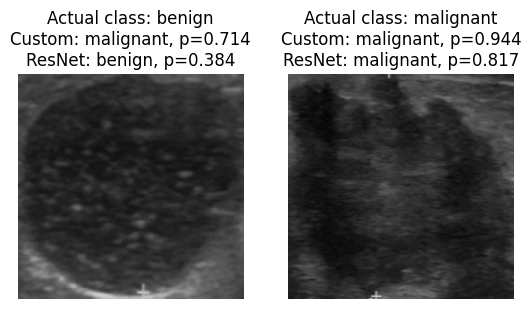

In [ ]:
# Class labels
idx  = lambda p: int(np.array(p>=0.5).item())
lbs = ['benign', 'malignant']

plt.subplot(1, 2, 1)
plt.imshow(imgB, cmap='gray')
plt.title(f'Actual class: benign\nCustom: {lbs[idx(p1B)]}, p={p1B.item():.3f}\nResNet: {lbs[idx(p2B)]}, p={p2B.item():.3f}')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(imgM, cmap='gray')
plt.title(f'Actual class: malignant\nCustom: {lbs[idx(p1M)]}, p={p1M.item():.3f}\nResNet: {lbs[idx(p2M)]}, p={p2M.item():.3f}')
plt.axis('off')
plt.show()